In [1]:
conda activate omfitenv


Note: you may need to restart the kernel to use updated packages.


In [2]:
from omfit_classes import omfit_eqdsk

In [3]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumtrapz
from scipy.constants import mu_0
import os

In [6]:
# FILES
#Change this
sim_index = 1

cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'
sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

sim = sims[sim_index]
work_dir = SCAN_dir+'/'+sim+'/work'

eq_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_eq_')]
#ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
gfile = work_dir+'/'+eq_dir[0]+'/g000001.00001'

toray_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_ec_')]
tfile = work_dir+'/'+toray_dir[0]+'/toray.nc'

print(gfile)

/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/angles_scan_HFS_more/SCAN/simulation_1917966_0006/work/fastran_eq_efit_45/g000001.00001


[[22.2858393  21.94033415 21.60644913 ...  7.50486328  7.4632548
   7.42196304]
 [22.28832493 21.94298054 21.6095872  ...  7.50883241  7.4670843
   7.42558564]
 [22.29016118 21.94492329 21.61201506 ...  7.5174616   7.4752576
   7.4332158 ]
 ...
 [22.31242859 21.96872173 21.63585263 ...  7.55453834  7.50937348
   7.46518261]
 [22.30761498 21.96397022 21.63120203 ...  7.54255562  7.4981923
   7.45486888]
 [22.30509649 21.96146118 21.62876389 ...  7.53769973  7.49364545
   7.45067774]]


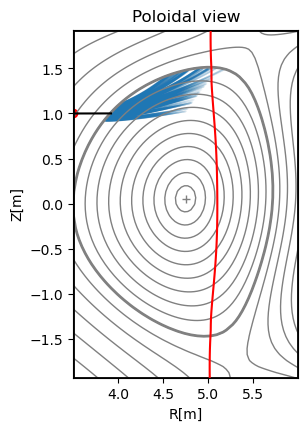

In [18]:
# ORIGINAL TORAY PLOTTING SCRIPT
#Python
# originally by Orso
# modified by Zhixuan 1/7/2015
data = Dataset(tfile)
geqdsk = omfit_eqdsk.OMFITgeqdsk(gfile)

phi_exp = 0
alpha = 0.1

# get/calculate physical quantites for rays
wr = data['wr'][:,:]#[::np.downsamp, ::np.downsamp]
mask = np.ones(wr.shape)
mask[np.where(wr == 0)] = np.nan
mask = mask.T

wphi = data['wphi'][:,:].T * mask
wr = wr.T * mask / 100.0
wx = wr * np.cos(wphi + phi_exp)
wy = wr * np.sin(wphi + phi_exp)

wz = data['wz'][:,:].T * mask / 100.0

x0t = data['x0'][0] / 100.0
y0t = data['y0'][0] / 100.0
R0t = np.sqrt(x0t**2 + y0t**2)
phi0t = np.arctan2(y0t, x0t)
x0 = R0t * np.cos(phi0t + phi_exp)
y0 = R0t * np.sin(phi0t + phi_exp)

z0 = data['z0'][0] / 100.0
x1 = wr[0, 0] * np.cos(wphi[0, 0] + phi_exp)
y1 = wr[0, 0] * np.sin(wphi[0, 0] + phi_exp)

z1 = data['wz'][:,:].T[0, 0] / 100.0

s = data['delpwr'][:,:].T
s = s / s[0]

# poloidal cross-section
plt.subplot(1, 2, 2)  # ,aspect='equal')

Zmax = max(geqdsk['ZLIM'])
Zmin = min(geqdsk['ZLIM'])
geqdsk.plot(only2D=True, color='grey') #POLOIDAL CROSS SECTION

# calculate the resonance field
#B_res = data['freqcy'][:] / 2.802e10
B_res = 2.8e11/2.802e10


# accurate resonant surface
R, Z = np.meshgrid(geqdsk['AuxQuantities']['R'], geqdsk['AuxQuantities']['Z'])
B = np.sqrt(geqdsk['AuxQuantities']['Bt'] ** 2 + geqdsk['AuxQuantities']['Br'] ** 2 + geqdsk['AuxQuantities']['Bz'] ** 2)
print(B)
plt.contour(R, Z, B, [B_res], colors='r') #POLODIAL RESONANT SURFACE

# approximate resonant surface, as the one shown in the toroidal view
t_angle = np.arange(0, 2 * np.pi, 0.02 * np.pi)
t_angle = np.append(t_angle, 2 * np.pi)
R_res = abs(geqdsk['RCENTR'] * geqdsk['BCENTR'] / B_res)
X_res = R_res * np.cos(t_angle)
Y_res = R_res * np.sin(t_angle)
#plt.plot([R_res, R_res], [Zmin, Zmax], 'r--') #POLODIAL APPROXIMATE RESONANT SURFACE?



plt.scatter(wr, wz, s, alpha=alpha)#, cmap='rainbow') ## POLOIDAL RAYS ##this used plotc, which colors the scatter points with a colorbar

plt.plot([R0t, wr[0, 0]], [z0, z1], 'k') ##POLOIDAL ANTENNA
plt.xlabel('R[m]')
plt.ylabel('Z[m]')

plt.title('Poloidal view')

plt.scatter(3.5,1,color='r')
plt.show()

Text(0.5, 1.0, 'Toroidal view')

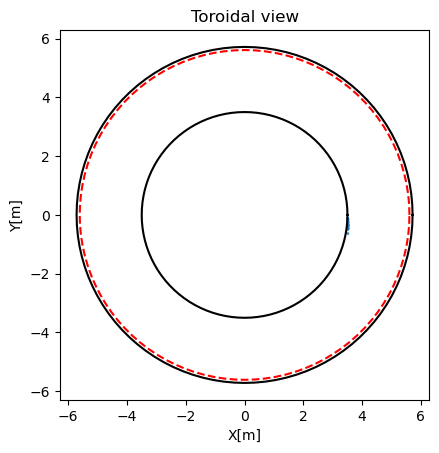

In [42]:
# toroidal cross-section
plt.subplot(1, 1, 1, aspect = 'equal')

plt.plot([x0, x1], [y0, y1], 'k') ## TOROIDAL ANTENNA
plt.xlabel('X[m]')
plt.ylabel('Y[m]')

plt.scatter(wx, wy, s * mask, alpha=alpha)#, cmap='rainbow') ## TORIODAL RAYS


# plot the boundary
Rout = max(geqdsk['RBBBS'])
Rin = min(geqdsk['RBBBS'])
t_angle = np.arange(0, 2 * np.pi, 0.02 * np.pi)
t_angle = np.append(t_angle, 2 * np.pi)
Xout = Rout * np.cos(t_angle)
Yout = Rout * np.sin(t_angle)
Xin = Rin * np.cos(t_angle)
Yin = Rin * np.sin(t_angle)
plt.plot(Xin, Yin, 'k') ##TOROIDAL BDRY
plt.plot(Xout, Yout, 'k') ##TOROIDAL BDRY

# calculate the resonance field
B_res = data['freqcy'][:] / 2.802e10

# approximate resonant surface
R_res = abs(geqdsk['RCENTR'] * geqdsk['BCENTR'] / B_res)
X_res = R_res * np.cos(t_angle)
Y_res = R_res * np.sin(t_angle)
plt.plot(X_res, Y_res, 'r--') #TOROIDAL RESONANT SURFACE

plt.title('Toroidal view')

In [42]:
# FFILE DATA
rootgrp = Dataset(ffile)

rho = rootgrp['rho'][:]

te = rootgrp['te'][-1,:]
ti = rootgrp['ti'][-1,:]

prfe = rootgrp['pe_rf'][-1,:]
prfe_int = rootgrp['prfe'][-1]
prfi = rootgrp['pi_rf'][-1,:]
prfi_int = rootgrp['prfi'][-1]

jbs = rootgrp['j_bs'][-1,:]
ibs = rootgrp['ibs'][-1]
jrf = rootgrp['j_rf'][-1,:]
irf = rootgrp['irf'][-1]
jtot = rootgrp['j_tot'][-1,:]




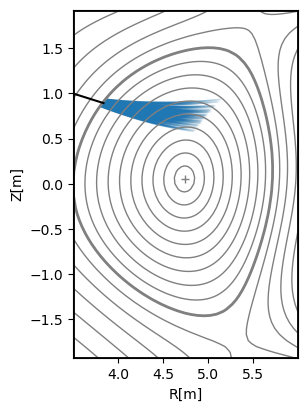

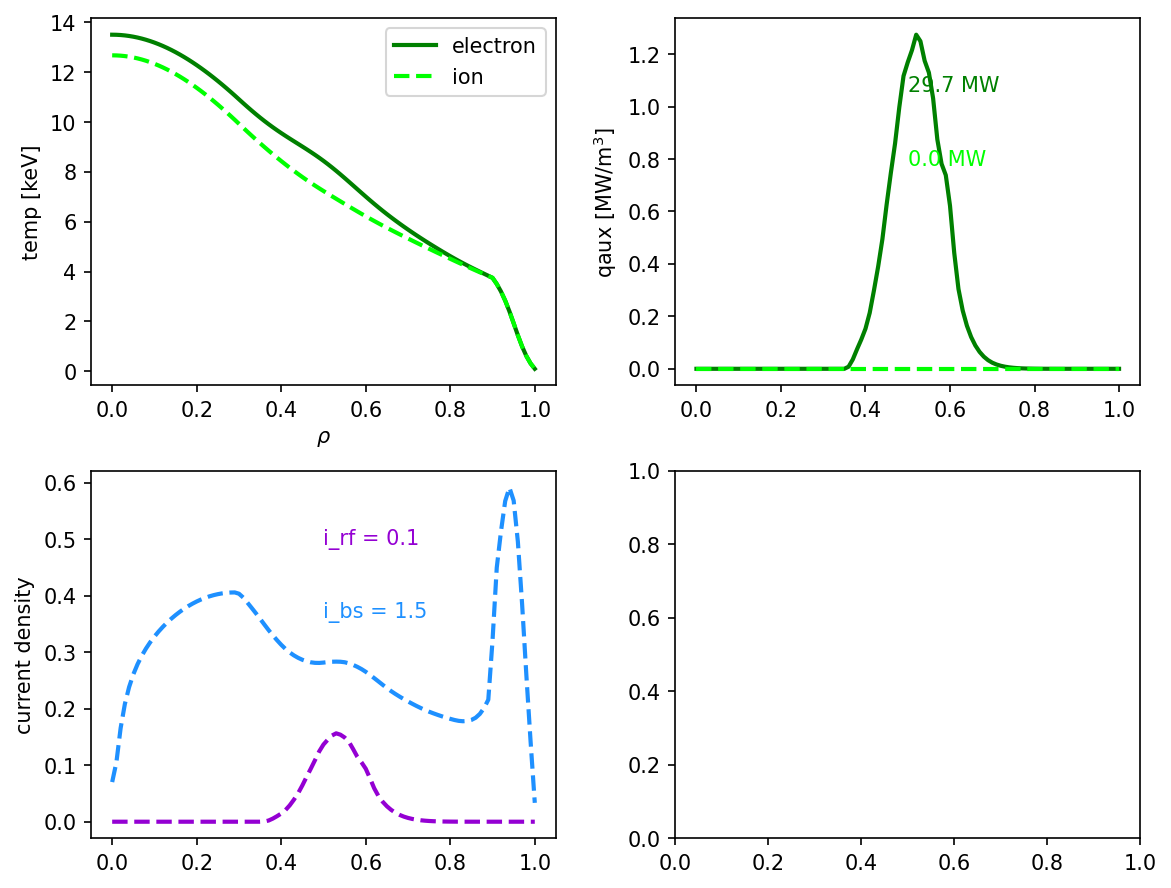

In [44]:
#PLOTS

# Plot poloidal cross section
plt.subplot(1, 2, 2, aspect='equal')
geqdsk.plot(only2D=True, color='grey') #POLOIDAL CROSS SECTION
plt.contour(R, Z, B, [B_res], colors='r') #POLODIAL RESONANT SURFACE
plt.scatter(wr, wz, s, alpha=alpha)#, cmap='rainbow') ## POLOIDAL RAYS ##this used plotc, which colors the scatter points with a colorbar

plt.plot([R0t, wr[0, 0]], [z0, z1], 'k') ##POLOIDAL ANTENNA
plt.xlabel('R[m]')
plt.ylabel('Z[m]')
plt.show()

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize =(8,6),dpi = 150)
lw = 2
c1 = 'green'
c2 = 'lime'
c3 = 'magenta'
c4 = 'darkviolet'
c5 = 'dodgerblue'
c6 = 'cyan'

# Plot temperature
ax1.plot(rho,te,color = c1,linewidth = lw, label = 'electron')
ax1.plot(rho,ti,color = c2,linewidth = lw,linestyle = 'dashed', label = 'ion')
ax1.set_ylabel('temp [keV]')
ax1.set_xlabel('$\\rho$')
ax1.legend()

# Plot heating
ax2.plot(rho,prfe,color = c1,linewidth = lw)
ax2.plot(rho,prfi,color = c2,linewidth = lw,linestyle = 'dashed')
ax2.set_ylabel('qaux [MW/m$^3$]')
ax2.text(0.5,0.8,'{:.1f} MW'.format(prfe_int),color = c1, transform = ax2.transAxes)
ax2.text(0.5,0.6,'{:.1f} MW'.format(prfi_int),color = c2, transform = ax2.transAxes)

# Plot current
ax3.plot(rho,jrf,color = c4,linewidth = lw,linestyle = 'dashed')
ax3.plot(rho,jbs,color = c5, linewidth =lw, linestyle='dashed')
ax3.text(0.5,0.8,'i_rf = {:.1f}'.format(irf),color = c4,transform = ax3.transAxes)
ax3.text(0.5,0.6,'i_bs = {:.1f}'.format(ibs),color = c5,transform = ax3.transAxes)
ax3.set_ylabel('current density')

fig.tight_layout()
plt.show()